In [1]:
# ============================================
# 🌍 AIR QUALITY PREDICTION SYSTEM
# ============================================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

In [3]:
# ============================================
# STEP 2 — LOAD DATASET
# ============================================

data = pd.read_csv("dataset.csv")

print("Dataset Loaded Successfully!")

data.head()


Dataset Loaded Successfully!


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [13]:
data.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3
count,13965.000000,13965.000000,13965.000000,13965.000000,13965.000000,13965.000000,13965.000000,13965.000000,13965.000000
mean,56.848004,116.275565,17.717347,28.395068,33.199731,21.005963,1.052962,11.476564,35.352046
std,51.364979,88.333599,23.447291,20.810108,31.103235,17.440638,1.183093,8.266981,21.720853
min,0.160000,0.180000,0.030000,0.010000,0.000000,0.060000,0.000000,0.010000,0.010000
25%,24.770000,55.720000,4.930000,12.340000,13.850000,9.350000,0.550000,6.140000,19.740000
50%,42.610000,94.440000,9.870000,23.980000,24.910000,15.730000,0.820000,9.610000,32.060000
75%,69.380000,145.850000,19.700000,39.120000,40.980000,28.250000,1.180000,14.020000,46.490000
max,685.360000,847.410000,270.090000,162.500000,293.100000,207.140000,30.440000,79.830000,257.730000


In [4]:
# ============================================
# STEP 3 — DATASET INFORMATION
# ============================================

print("Dataset Shape:")
print(data.shape)

print("\nColumns:")
print(data.columns)

print("\nDataset Info:")
print(data.info())

Dataset Shape:
(29531, 16)

Columns:
Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI      

In [5]:
# ============================================
# STEP 4 — CHECK MISSING VALUES
# ============================================

print("\nMissing Values:")
print(data.isnull().sum())


Missing Values:
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64


In [6]:
# ============================================
# STEP 5 — DATA CLEANING
# ============================================

# Select important columns

data = data[[
    'PM2.5',
    'PM10',
    'NO',
    'NO2',
    'NOx',
    'NH3',
    'CO',
    'SO2',
    'O3',
    'AQI_Bucket'
]]

# Remove missing values

data = data.dropna()

print("\nCleaned Dataset Shape:")
print(data.shape)

data.head()


Cleaned Dataset Shape:
(13965, 10)


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,AQI_Bucket
2010,31.21,38.66,7.20,1.27,10.65,25.63,0.56,4.22,2.81,Satisfactory
2011,38.39,46.68,7.19,0.91,10.37,29.16,0.57,4.46,0.18,Satisfactory
2012,43.23,50.83,7.14,1.07,10.48,28.95,0.57,4.53,0.41,Satisfactory
2013,33.82,41.03,7.09,0.36,9.73,28.41,0.48,4.63,0.30,Satisfactory
2014,27.14,35.04,5.63,2.32,8.09,23.98,0.50,4.71,13.02,Satisfactory


In [7]:
# ============================================
# STEP 6 — DATA MANIPULATION
# ============================================

print("\nAQI Category Count:")
print(data['AQI_Bucket'].value_counts())


AQI Category Count:
AQI_Bucket
Satisfactory    5350
Moderate        5123
Poor            1335
Good            1024
Very Poor        850
Severe           283
Name: count, dtype: int64


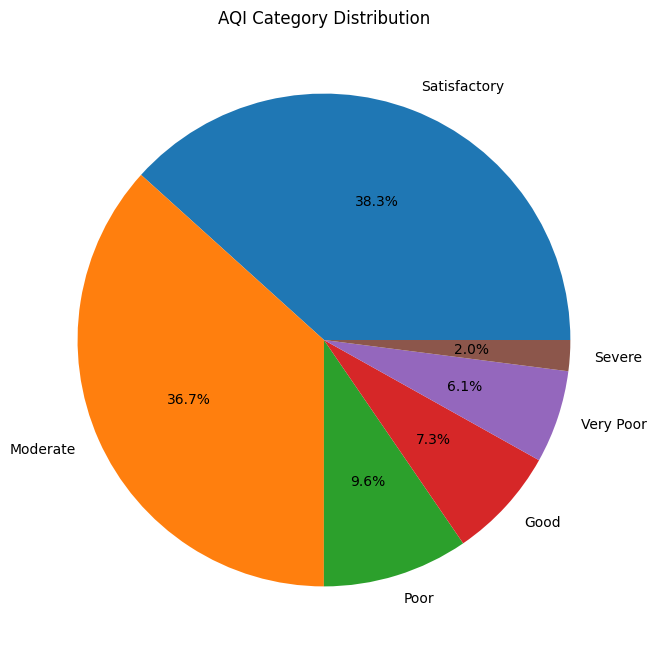

In [8]:
# ============================================
# STEP 7 — DATA VISUALIZATION
# ============================================

# AQI Distribution Pie Chart

plt.figure(figsize=(8,8))

data['AQI_Bucket'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("AQI Category Distribution")

plt.ylabel("")

plt.show()

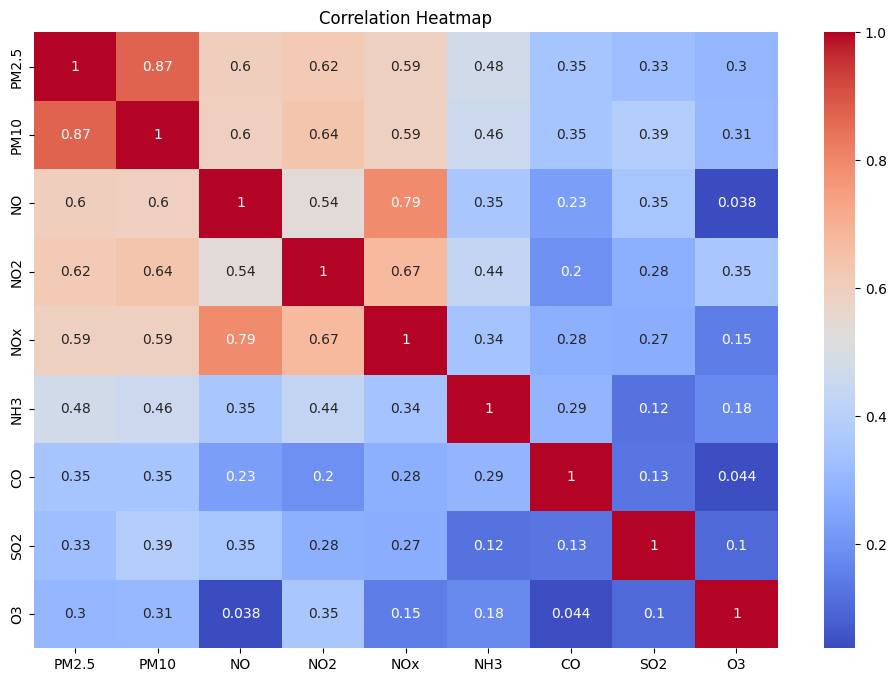

In [9]:
# ============================================
# STEP 8 — CORRELATION HEATMAP
# ============================================

plt.figure(figsize=(12,8))

sns.heatmap(
    data.drop('AQI_Bucket', axis=1).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [10]:
# ============================================
# STEP 9 — FEATURES & TARGET
# ============================================

X = data[[
    'PM2.5',
    'PM10',
    'NO',
    'NO2',
    'NOx',
    'NH3',
    'CO',
    'SO2',
    'O3'
]]

y = data['AQI_Bucket']

In [11]:
# ============================================
# STEP 10 — LABEL ENCODING
# ============================================

encoder = LabelEncoder()

y = encoder.fit_transform(y)

print("\nEncoded Classes:")
print(encoder.classes_)



Encoded Classes:
['Good' 'Moderate' 'Poor' 'Satisfactory' 'Severe' 'Very Poor']


In [12]:
# ============================================
# STEP 11 — TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (11172, 9)
Testing Data Shape: (2793, 9)


In [13]:
# ============================================
# STEP 12 — DECISION TREE CLASSIFIER
# ============================================

dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

dt_precision = precision_score(y_test, dt_pred, average='weighted')

dt_recall = recall_score(y_test, dt_pred, average='weighted')

dt_f1 = f1_score(y_test, dt_pred, average='weighted')

print("\nDecision Tree Accuracy:", dt_acc)



Decision Tree Accuracy: 0.7626208378088077


In [14]:
# ============================================
# STEP 13 — KNN CLASSIFIER
# ============================================

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)

knn_precision = precision_score(y_test, knn_pred, average='weighted')

knn_recall = recall_score(y_test, knn_pred, average='weighted')

knn_f1 = f1_score(y_test, knn_pred, average='weighted')

print("\nKNN Accuracy:", knn_acc)



KNN Accuracy: 0.7984246330110992


In [15]:
# ============================================
# STEP 14 — RANDOM FOREST CLASSIFIER
# ============================================

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(y_test, rf_pred, average='weighted')

rf_recall = recall_score(y_test, rf_pred, average='weighted')

rf_f1 = f1_score(y_test, rf_pred, average='weighted')

print("\nRandom Forest Accuracy:", rf_acc)


Random Forest Accuracy: 0.8385248836376656


In [16]:
# ============================================
# STEP 15 — PERFORMANCE COMPARISON TABLE
# ============================================

results = pd.DataFrame({

    'Algorithm': [
        'Decision Tree',
        'KNN',
        'Random Forest'
    ],

    'Accuracy': [
        dt_acc,
        knn_acc,
        rf_acc
    ],

    'Precision': [
        dt_precision,
        knn_precision,
        rf_precision
    ],

    'Recall': [
        dt_recall,
        knn_recall,
        rf_recall
    ],

    'F1 Score': [
        dt_f1,
        knn_f1,
        rf_f1
    ]
})

print("\nPerformance Comparison:")
print(results)


Performance Comparison:
       Algorithm  Accuracy  Precision    Recall  F1 Score
0  Decision Tree  0.762621   0.763235  0.762621  0.762660
1            KNN  0.798425   0.798041  0.798425  0.797915
2  Random Forest  0.838525   0.837723  0.838525  0.837649


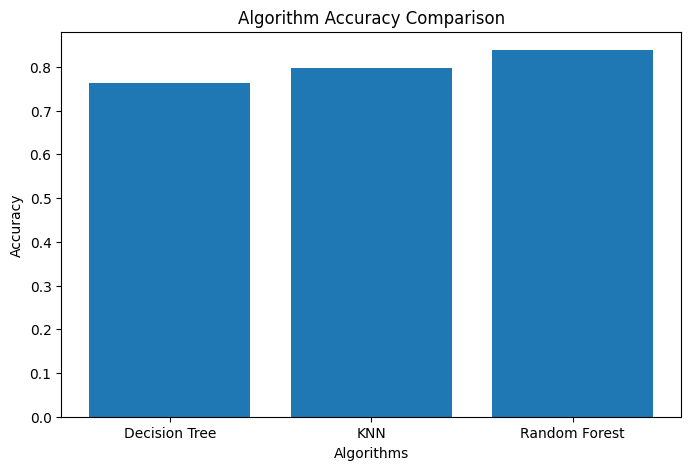

In [17]:
# ============================================
# STEP 16 — ACCURACY COMPARISON GRAPH
# ============================================

plt.figure(figsize=(8,5))

plt.bar(
    results['Algorithm'],
    results['Accuracy']
)

plt.title("Algorithm Accuracy Comparison")

plt.xlabel("Algorithms")

plt.ylabel("Accuracy")

plt.show()


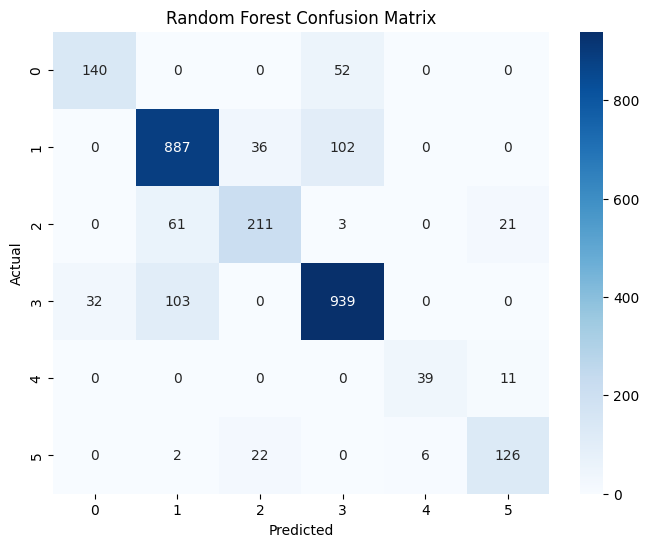

In [18]:
# ============================================
# STEP 17 — CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

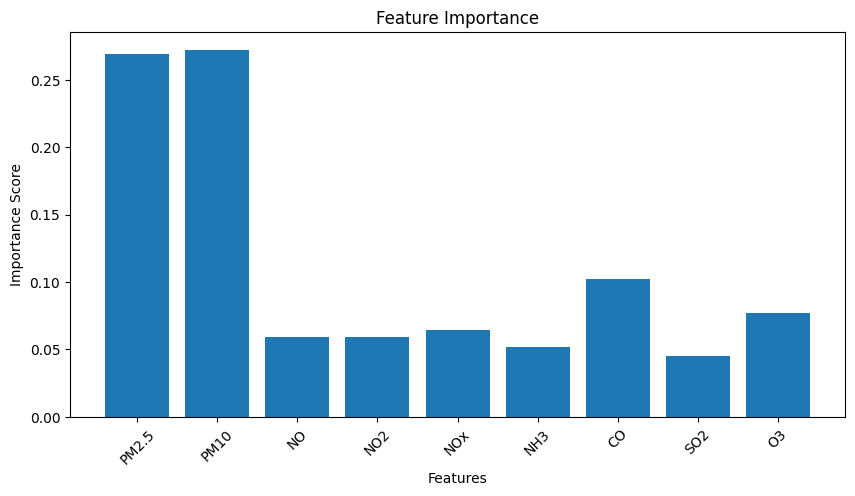

In [19]:
# ============================================
# STEP 18 — FEATURE IMPORTANCE GRAPH
# ============================================

importance = rf.feature_importances_

features = X.columns

plt.figure(figsize=(10,5))

plt.bar(features, importance)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance Score")

plt.xticks(rotation=45)

plt.show()


In [20]:
# ============================================
# STEP 19 — CLASSIFICATION REPORT
# ============================================

print("\nRandom Forest Classification Report:\n")

print(classification_report(y_test, rf_pred))


Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.73      0.77       192
           1       0.84      0.87      0.85      1025
           2       0.78      0.71      0.75       296
           3       0.86      0.87      0.87      1074
           4       0.87      0.78      0.82        50
           5       0.80      0.81      0.80       156

    accuracy                           0.84      2793
   macro avg       0.83      0.79      0.81      2793
weighted avg       0.84      0.84      0.84      2793



In [21]:
# ============================================
# STEP 20 — BEST MODEL SELECTION
# ============================================

print("\nBest Algorithm:")

if rf_acc > dt_acc and rf_acc > knn_acc:
    print("Random Forest Classifier")

elif dt_acc > knn_acc:
    print("Decision Tree Classifier")

else:
    print("KNN Classifier")


Best Algorithm:
Random Forest Classifier


In [22]:
# ============================================
# STEP 21 — SAVE MODEL
# ============================================

import joblib

joblib.dump(rf, "best_model.pkl")

print("\nModel Saved Successfully!")


Model Saved Successfully!
